# TC Track-Density Maps - Four Historical Runs

Compare the four runs used by `plot_2d_map.ipynb` using the 10-year TempestExtremes tracking outputs already present in each simulation directory.

The default diagnostic reads `*_TCS_Track_*.txt`, counts TC track points on a 5-degree grid, and annualizes by each run's `nyears`. Set `DENSITY_SOURCE = "histogram"` to plot the precomputed `*_TCS_hist_gram_*.nc` files instead.


In [129]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "scripts").exists() and (PROJECT_ROOT.parent / "scripts").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SCRIPTS_DIR = PROJECT_ROOT / "scripts"
if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

from tc_track_density import TrackDensityConfig, compute_track_density

# PROJ data path: normally provided by the active analysis kernel.
_proj_path = Path(os.environ.get("CONDA_PREFIX", "")) / "share" / "proj"
if _proj_path.exists():
    os.environ["PROJ_LIB"] = str(_proj_path)
    os.environ["PROJ_DATA"] = str(_proj_path)

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"SCRIPTS_DIR : {SCRIPTS_DIR}")
print(f"Python      : {sys.executable}")


PROJECT_ROOT: /pscratch/sd/z/zhan391/e3smv4_project/allhands_meeting/pcmdi_package
SCRIPTS_DIR : /pscratch/sd/z/zhan391/e3smv4_project/allhands_meeting/pcmdi_package/scripts
Python      : /global/homes/z/zhan391/.conda/envs/zi-pcmdi-diags/bin/python


## Configuration

In [ ]:
E3SMV4_ROOT = Path("/pscratch/sd/z/zhan391/e3smv4_project")
OUTPUT_DIR = Path("/global/cfs/cdirs/e3sm/www/zhan391/eamxx-pcmdi/analysis_output/tc_track_density")

# "track_points" uses *_TCS_Track_*.txt and computes a true track-point density.
# "histogram" uses the precomputed *_TCS_hist_gram_*.nc files.
DENSITY_SOURCE = "track_points"  # "track_points" or "histogram"
GRID_SIZE = 5.0
ANNUALIZE = True
RUN_PLOTS = True
SAVE_FIGURES = True

# Model TC tracking criteria used upstream by TempestExtremes. The notebook does
# not re-filter model tracks; these controls document the model-track definition
# and set matching defaults for observation filters where possible.
MODEL_MIN_WIND_MS = 8.0
MODEL_MAX_TOPOGRAPH_M = 150.0

# IBTrACS observation filtering. Model tracks are 6-hourly, so observations use
# the same wind threshold and synoptic cadence before computing track density.
OBS_WIND_MIN_MS = MODEL_MIN_WIND_MS
MS_TO_KT = 1.9438444924406046
OBS_WIND_MIN_KT = OBS_WIND_MIN_MS * MS_TO_KT
OBS_WIND_VARIABLES = [
    "wmo_wind",
    "usa_wind",
    "tokyo_wind",
    "cma_wind",
    "reunion_wind",
    "bom_wind",
    "newdelhi_wind",
    "wellington_wind",
]
OBS_MATCH_MODEL_6HOURLY = True
OBS_SYNOPTIC_HOURS = [0, 6, 12, 18]

# IBTrACS has no native topography variable. Leave OBS_TOPOGRAPHY_PATH as None
# to skip obs topography filtering, or set it to a lat-lon NetCDF topography file
# with units of meters to apply the same max-topography threshold to observations.
OBS_MAX_TOPOGRAPH_M = MODEL_MAX_TOPOGRAPH_M
OBS_TOPOGRAPHY_PATH = None
OBS_TOPOGRAPHY_VAR = None

INCLUDE_OBS_REFERENCE = True
OBS_RUN = {
    "label": "IBTrACS",
    "source": "obs",
    "path": Path("/global/cfs/cdirs/e3sm/zhan391/TempestExtremes/OBS/tc_track/IBTrACS/IBTrACS.since1980.v04r00.nc"),
    "year_start": 1995,
    "year_end": 2004,
}
OBS_RUN["year_range"] = f"{OBS_RUN['year_start']}-{OBS_RUN['year_end']}"
OBS_RUN["nyears"] = OBS_RUN["year_end"] - OBS_RUN["year_start"] + 1

TC_RUNS = [
    {
        "label": "v3.LR.CPL",
        "source": "model",
        "case": "20231209.v3.LR.piControl-spinup.chrysalis",
        "tc_name": "piControl-spinup",
        "year_range": "1-10",
        "nyears": 10,
        "hist_file": "piControl-spinup_set2_TCS_hist_gram_1-10.nc",
        "track_file": "piControl-spinup_set2_TCS_Track_1-10.txt",
    },
    {
        "label": "v3.HR.CPL",
        "source": "model",
        "case": "20250906.wcycl1850.ne120pg2_r025_RRSwISC6to18E3r5.test6.1.chrysalis",
        "tc_name": "v3.LR.piControl-spinup",
        "year_range": "81-90",
        "nyears": 10,
        "hist_file": "v3.LR.piControl-spinup_set2_TCS_hist_gram_81-90.nc",
        "track_file": "v3.LR.piControl-spinup_set2_TCS_Track_81-90.txt",
    },
    {
        "label": "v4P.CPL",
        "source": "model",
        "case": "20260204.ne256.WCYCLXX1850.SOI",
        "tc_name": "WCYCLXX1850.SOI",
        "year_range": "1-10",
        "nyears": 10,
        "hist_file": "WCYCLXX1850.SOI_set2_TCS_hist_gram_1-10.nc",
        "track_file": "WCYCLXX1850.SOI_set2_TCS_Track_1-10.txt",
    },
    {
        "label": "v4P.AMIP",
        "source": "model",
        "case": "ne256pg2_ne256pg2.F20TR-SCREAMv1.July-1.spanc800.2xauto.acc150.n0032.test2.1",
        "tc_name": "F20TR-SCREAMv1.ne256pg2",
        "year_range": "1995-2004",
        "nyears": 10,
        "hist_file": "F20TR-SCREAMv1.ne256pg2_set2_TCS_hist_gram_1995-2004.nc",
        "track_file": "F20TR-SCREAMv1.ne256pg2_set2_TCS_Track_1995-2004.txt",
    },
]

for run in TC_RUNS:
    run["analysis_dir"] = E3SMV4_ROOT / run["case"] / "post" / "atm" / "tc-analysis"
    run["hist_path"] = run["analysis_dir"] / run["hist_file"]
    run["track_path"] = run["analysis_dir"] / run["track_file"]

PLOT_RUNS = ([OBS_RUN] if INCLUDE_OBS_REFERENCE else []) + TC_RUNS

PLOT_EXTENT = [0, 360, -70, 70]
FIGSIZE = (20, 16.0) if INCLUDE_OBS_REFERENCE else (14.5, 8.8)
DPI = 300
CMAP = "YlOrRd"
LEVEL_MODE = "fixed"  # "auto" or "fixed"
FIXED_LEVELS = np.arange(0, 28, 2)

# Figure appearance. Adjust FIG_FONT_SIZE first; dependent sizes scale from it.
FIG_FONT_SIZE = 18.0
FIG_SUPTITLE_SIZE = FIG_FONT_SIZE * 1.2
FIG_PANEL_TITLE_SIZE = FIG_FONT_SIZE * 1.0
FIG_TICK_SIZE = FIG_FONT_SIZE * 0.95
FIG_PANEL_LABEL_SIZE = FIG_FONT_SIZE * 0.95
FIG_ANNOTATION_SIZE = FIG_FONT_SIZE * 0.9
FIG_COLORBAR_LABEL_SIZE = FIG_FONT_SIZE * 0.95
FIG_COLORBAR_TICK_SIZE = FIG_FONT_SIZE * 0.9
FIG_FOOTNOTE_SIZE = FIG_FONT_SIZE * 0.85
FIG_TITLE_PAD = 5
FIG_TICK_LENGTH = 3.2
FIG_TICK_WIDTH = 0.7
FIG_TICK_PAD = 2
FIG_COASTLINE_LINEWIDTH = 0.55
FIG_SPINE_LINEWIDTH = 0.85
FIG_PANEL_LABEL_XY = (0.015, 0.92)
FIG_TOTAL_LABEL_XY = (0.015, 0.055)
FIG_LABEL_BOX_ALPHA = 0.82
FIG_COLORBAR_LABEL_PAD = 4
FIG_SUPTITLE_Y = 0.975
FIG_FOOTNOTE_XY = (0.985, 0.025)
FIG_GRID_LEFT = 0.055
FIG_GRID_RIGHT = 0.985
FIG_GRID_TOP_WITH_OBS = 0.91
FIG_GRID_TOP_DEFAULT = 0.90
FIG_GRID_BOTTOM_WITH_OBS = 0.075
FIG_GRID_BOTTOM_DEFAULT = 0.085
FIG_PANEL_HSPACE = 0.24
FIG_PANEL_WSPACE = 0.075
FIG_COLORBAR_HEIGHT_RATIO = 0.12

# TC basin overlays from Knutson et al. (2020, BAMS), using 0-360 longitude.
SHOW_TC_BASINS = True
SHOW_TC_BASIN_LABELS = True
INCLUDE_SOUTH_ATLANTIC_BASINS = False
TC_BASIN_LINEWIDTH = FIG_SPINE_LINEWIDTH * 1.20
TC_BASIN_LINESTYLE = "--"
TC_BASIN_EDGE_COLOR = "0.20"
TC_BASIN_LABEL_SIZE = FIG_FONT_SIZE * 0.78
TC_BASIN_LABEL_COLOR = "0.10"
TC_BASIN_LABEL_ALPHA = 0.78
TC_BASIN_COUNT_DECIMALS = 1
TC_PANEL_TOTAL_DECIMALS = 1
TC_MAIN_BASINS = {
    "NA":  {"lon1": 265, "lon2": 360, "lat1": 0,   "lat2": 90, "text_xy": (305, 58)},
    "NEP": {"lon1": 180, "lon2": 265, "lat1": 0,   "lat2": 90, "text_xy": (215, 58)},
    "NWP": {"lon1": 100, "lon2": 180, "lat1": 0,   "lat2": 90, "text_xy": (135, 58)},
    "NI":  {"lon1": 30,  "lon2": 100, "lat1": 0,   "lat2": 90, "text_xy": (60, 58)},
    "SI":  {"lon1": 20,  "lon2": 135, "lat1": -90, "lat2": 0,  "text_xy": (65, -50)},
    "SWP": {"lon1": 135, "lon2": 295, "lat1": -90, "lat2": 0,  "text_xy": (215, 
                                                                           0)},
}
TC_OPTIONAL_BASINS = {
    "SA1": {"lon1": 295, "lon2": 360, "lat1": -90, "lat2": 0,  "text_xy": (325, -35)},
    "SA2": {"lon1": 0,   "lon2": 20,  "lat1": 0,   "lat2": 90, "text_xy": (10, 58)},
}
TC_BASINS = TC_MAIN_BASINS.copy()
if INCLUDE_SOUTH_ATLANTIC_BASINS:
    TC_BASINS.update(TC_OPTIONAL_BASINS)

# ENSO regression controls. The notebook can generate consistent Niño-3.4
# index files from the same 10-year monthly TS files used for these runs.
RUN_ENSO_REGRESSION = True
REG_GENERATE_NINO_FILES = True
REG_NINO_VAR = "nino34"
REG_NINO_MONTHS = None  # None = annual mean; e.g., [6, 7, 8, 9, 10, 11] for NH TC season.
REG_NINO_LAT_BOUNDS = (-5.0, 5.0)
REG_NINO_LON_BOUNDS = (190.0, 240.0)  # 170W-120W in 0-360 longitude.
REG_SST_VAR = None  # None guesses TS/ts/SST/sst.
REG_NINO_SOURCE = "monthly_ts"
REG_NINO_FILE = None
REG_MIN_YEARS = 3
REG_CONFIDENCE = 0.90
REG_SHOW_SIGNIFICANCE_MARKERS = True
REG_SIGNIFICANCE_MARKER_SIZE = FIG_FONT_SIZE * 0.16
REG_SIGNIFICANCE_MARKER_STRIDE = 1
REG_LEVEL_MODE = "fixed"  # "auto" or "fixed"
REG_FIXED_LEVELS = np.arange(-5.0, 5.0, 0.5)
REG_COLOR_LIMIT_MIN = 50.0
REG_COLOR_LIMIT_PERCENTILE = 98.0
REG_CMAP = "RdBu_r"
REG_FIGSIZE = FIGSIZE
REG_SST_FILE_PATTERN = "post/atm/180x360_aave/cmip_ts/monthly/ts_Amon_E3SM-1-0_piControl_r1i1p1f1_gr_*.nc"
REG_SST_FILE_BY_LABEL = {
    run["label"]: sorted((E3SMV4_ROOT / run["case"]).glob(REG_SST_FILE_PATTERN))
    for run in TC_RUNS
}
# Use the AMIP prescribed-SST index for IBTrACS unless an independent observed SST
# file is supplied below.
REG_SST_FILE_BY_LABEL["IBTrACS"] = REG_SST_FILE_BY_LABEL.get("v4P.AMIP", [])
REG_NINO_FILE_BY_LABEL = {
    run["label"]: OUTPUT_DIR / f"nino34_{run['label'].replace('.', '-').replace(' ', '_')}_{run['year_range']}.nc"
    for run in PLOT_RUNS
}
# To use a precomputed index for any panel, override that label here.
# REG_NINO_FILE_BY_LABEL["IBTrACS"] = Path("/path/to/observed_nino34.nc")


## Validate Inputs

In [131]:
if DENSITY_SOURCE not in {"track_points", "histogram"}:
    raise ValueError('DENSITY_SOURCE must be "track_points" or "histogram"')

missing = []
if INCLUDE_OBS_REFERENCE and not OBS_RUN["path"].exists():
    missing.append((OBS_RUN["label"], OBS_RUN["path"]))
if INCLUDE_OBS_REFERENCE and OBS_TOPOGRAPHY_PATH is not None and not Path(OBS_TOPOGRAPHY_PATH).exists():
    missing.append(("obs topography", Path(OBS_TOPOGRAPHY_PATH)))
for run in TC_RUNS:
    required_path = run["track_path"] if DENSITY_SOURCE == "track_points" else run["hist_path"]
    if not required_path.exists():
        missing.append((run["label"], required_path))

if missing:
    raise FileNotFoundError(
        "Missing TC-analysis inputs:\n" + "\n".join(f"  {label}: {path}" for label, path in missing)
    )

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Density source: {DENSITY_SOURCE}")
print(f"Output dir    : {OUTPUT_DIR}")
print(f"Model filter  : minWind={MODEL_MIN_WIND_MS:g} m/s; max_topograph={MODEL_MAX_TOPOGRAPH_M:g} m; 6-hourly tracks")
if INCLUDE_OBS_REFERENCE:
    print("Observation input:")
    print(f"  {OBS_RUN['label']} ({OBS_RUN['year_range']}, {OBS_RUN['nyears']} years): {OBS_RUN['path']}")
    print(
        f"  wind filter : max({', '.join(OBS_WIND_VARIABLES)}) >= "
        f"{OBS_WIND_MIN_MS:g} m/s ({OBS_WIND_MIN_KT:.1f} kt)"
    )
    if OBS_MATCH_MODEL_6HOURLY:
        print(f"  time filter : hours {OBS_SYNOPTIC_HOURS}, matching 6-hourly model tracks")
    if OBS_TOPOGRAPHY_PATH is None:
        print("  topo filter : not applied to IBTrACS; set OBS_TOPOGRAPHY_PATH to enable")
    else:
        print(f"  topo filter : {OBS_TOPOGRAPHY_PATH}, {OBS_TOPOGRAPHY_VAR or 'auto'} <= {OBS_MAX_TOPOGRAPH_M:g} m")
print("Resolved model TC-analysis inputs:")
for run in TC_RUNS:
    print(f"  {run['label']} ({run['year_range']}, {run['nyears']} years)")
    print(f"    track: {run['track_path']}")
    print(f"    hist : {run['hist_path']}")


Density source: track_points
Output dir    : /global/cfs/cdirs/e3sm/www/zhan391/eamxx-pcmdi/analysis_output/tc_track_density
Model filter  : minWind=8 m/s; max_topograph=150 m; 6-hourly tracks
Observation input:
  IBTrACS (1995-2004, 10 years): /global/cfs/cdirs/e3sm/zhan391/TempestExtremes/OBS/tc_track/IBTrACS/IBTrACS.since1980.v04r00.nc
  wind filter : max(wmo_wind, usa_wind, tokyo_wind, cma_wind, reunion_wind, bom_wind, newdelhi_wind, wellington_wind) >= 8 m/s (15.6 kt)
  time filter : hours [0, 6, 12, 18], matching 6-hourly model tracks
  topo filter : not applied to IBTrACS; set OBS_TOPOGRAPHY_PATH to enable
Resolved model TC-analysis inputs:
  v3.LR.CPL (1-10, 10 years)
    track: /pscratch/sd/z/zhan391/e3smv4_project/20231209.v3.LR.piControl-spinup.chrysalis/post/atm/tc-analysis/piControl-spinup_set2_TCS_Track_1-10.txt
    hist : /pscratch/sd/z/zhan391/e3smv4_project/20231209.v3.LR.piControl-spinup.chrysalis/post/atm/tc-analysis/piControl-spinup_set2_TCS_hist_gram_1-10.nc
  v3.H

## Load Track Density

In [132]:
def parse_stitchnodes_track(path: Path) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Return lat, lon, and storm ids from a TempestExtremes StitchNodes track file."""
    lat = []
    lon = []
    storm_id = []
    current_storm = -1

    with open(path) as fh:
        for line in fh:
            text = line.strip()
            if not text or text.startswith("#"):
                continue
            if text.startswith("start"):
                current_storm += 1
                continue

            parts = text.split()
            if len(parts) >= 10 and abs(float(parts[3])) <= 90.0:
                # Historical aggregate Track files include i, j, lon, lat, ...
                lon_value = float(parts[2])
                lat_value = float(parts[3])
            elif len(parts) >= 10:
                # Hindcast/member Track files use i, lon, lat, slp, wind, zs, ...
                lon_value = float(parts[1])
                lat_value = float(parts[2])
            else:
                continue
            lon.append(lon_value % 360.0)
            lat.append(lat_value)
            storm_id.append(current_storm)

    return np.asarray(lat), np.asarray(lon), np.asarray(storm_id)


def load_track_point_density(run: dict) -> xr.DataArray:
    lat, lon, storm_id = parse_stitchnodes_track(run["track_path"])
    config = TrackDensityConfig(method="box", box_grid_size=GRID_SIZE)
    density = compute_track_density(lat, lon, track_id=storm_id, config=config)
    density.name = "track_density"
    density.attrs.update(
        source=str(run["track_path"]),
        diagnostic=f"TC track points per {GRID_SIZE:g} degree grid box",
        raw_count=float(density.sum()),
    )
    return density


def _find_lat_lon_names(ds: xr.Dataset) -> tuple[str, str]:
    lat_candidates = ["lat", "latitude", "grid_lat"]
    lon_candidates = ["lon", "longitude", "grid_lon"]
    lat_name = next((name for name in lat_candidates if name in ds.coords or name in ds.dims or name in ds.data_vars), None)
    lon_name = next((name for name in lon_candidates if name in ds.coords or name in ds.dims or name in ds.data_vars), None)
    if lat_name is None or lon_name is None:
        raise ValueError(f"Could not identify lat/lon coordinates in {list(ds.coords)} / {list(ds.dims)}")
    return lat_name, lon_name


def load_histogram_density(run: dict) -> xr.DataArray:
    ds = xr.open_dataset(run["hist_path"])
    lat_name, lon_name = _find_lat_lon_names(ds)
    candidates = [name for name, da in ds.data_vars.items() if lat_name in da.dims and lon_name in da.dims]
    if not candidates:
        raise ValueError(f"No lat-lon data variable found in {run['hist_path']}")
    varname = "density" if "density" in candidates else candidates[0]
    density = ds[varname]
    sum_dims = [dim for dim in density.dims if dim not in {lat_name, lon_name}]
    if sum_dims:
        density = density.sum(dim=sum_dims, skipna=True)
    density = density.rename({lat_name: "lat", lon_name: "lon"})
    density = density.assign_coords(lon=(density["lon"] % 360.0)).sortby("lon")
    density.name = "histogram_density"
    density.attrs.update(source=str(run["hist_path"]), variable=varname)
    return density


def _ibtracs_time_values(ds: xr.Dataset) -> xr.DataArray:
    if "time" in ds:
        return ds["time"]
    if "iso_time" not in ds:
        raise ValueError("IBTrACS file has neither 'time' nor 'iso_time'.")

    iso = ds["iso_time"]
    if iso.dtype.kind in {"S", "U", "O"}:
        return xr.apply_ufunc(np.datetime64, iso, vectorize=True)

    # Some IBTrACS NetCDF builds store iso_time as a character array with an
    # extra string-length dimension. Prefer xarray's character decoding when available.
    decoded = xr.decode_cf(ds[["iso_time"]])["iso_time"]
    return xr.apply_ufunc(np.datetime64, decoded, vectorize=True)


def _combined_ibtracs_wind(ds: xr.Dataset, wind_variables: list[str]) -> xr.DataArray | None:
    wind_fields = [ds[name] for name in wind_variables if name in ds]
    if not wind_fields:
        return None
    return xr.concat(wind_fields, dim="wind_source").max("wind_source", skipna=True)


def _find_topography_variable(ds: xr.Dataset, preferred: str | None = None) -> str:
    if preferred is not None:
        if preferred not in ds:
            raise ValueError(f"OBS_TOPOGRAPHY_VAR={preferred!r} is not in {list(ds.data_vars)}")
        return preferred
    candidates = ["topography", "topo", "orog", "elev", "elevation", "zs", "PHIS", "phis"]
    for name in candidates:
        if name in ds.data_vars:
            return name
    for name, da in ds.data_vars.items():
        units = str(da.attrs.get("units", "")).lower()
        long_name = str(da.attrs.get("long_name", "")).lower()
        if "m" in units and any(token in long_name for token in ["topography", "elevation", "surface height", "orography"]):
            return name
    raise ValueError("Could not identify a topography variable. Set OBS_TOPOGRAPHY_VAR explicitly.")


def _obs_topography_at_points(lat_values: np.ndarray, lon_values: np.ndarray) -> np.ndarray | None:
    if OBS_TOPOGRAPHY_PATH is None:
        return None
    ds_topo = xr.open_dataset(OBS_TOPOGRAPHY_PATH)
    topo_name = _find_topography_variable(ds_topo, OBS_TOPOGRAPHY_VAR)
    topo = ds_topo[topo_name]
    lat_name, lon_name = _find_lat_lon_names(ds_topo)
    if lat_name != "lat" or lon_name != "lon":
        topo = topo.rename({lat_name: "lat", lon_name: "lon"})
    topo = topo.assign_coords(lon=(topo["lon"] % 360.0)).sortby("lon")
    sample = topo.interp(
        lat=xr.DataArray(lat_values, dims="point"),
        lon=xr.DataArray(lon_values % 360.0, dims="point"),
        method="nearest",
    )
    return np.asarray(sample.values, dtype=float)


def load_ibtracs_density(run: dict) -> xr.DataArray:
    ds = xr.open_dataset(run["path"], decode_times=True)
    lat_name, lon_name = _find_lat_lon_names(ds)
    lat = ds[lat_name]
    lon = ds[lon_name]
    time = _ibtracs_time_values(ds)

    mask = np.isfinite(lat) & np.isfinite(lon)
    if np.issubdtype(time.dtype, np.datetime64):
        years = time.dt.year
        mask = mask & (years >= run["year_start"]) & (years <= run["year_end"])
        if OBS_MATCH_MODEL_6HOURLY:
            mask = mask & time.dt.hour.isin(OBS_SYNOPTIC_HOURS)
    else:
        print("[WARN] Could not decode IBTrACS time; using all available observation times.")

    wind = _combined_ibtracs_wind(ds, OBS_WIND_VARIABLES)
    if wind is None:
        print("[WARN] No configured IBTrACS wind variables found; skipping wind filter.")
    else:
        mask = mask & np.isfinite(wind) & (wind >= OBS_WIND_MIN_KT)

    lat_values = lat.where(mask).values.ravel()
    lon_values = lon.where(mask).values.ravel()
    valid = np.isfinite(lat_values) & np.isfinite(lon_values)
    lat_values = lat_values[valid]
    lon_values = lon_values[valid]

    topo_values = _obs_topography_at_points(lat_values, lon_values)
    if topo_values is not None:
        topo_valid = np.isfinite(topo_values) & (topo_values <= OBS_MAX_TOPOGRAPH_M)
        lat_values = lat_values[topo_valid]
        lon_values = lon_values[topo_valid]

    config = TrackDensityConfig(method="box", box_grid_size=GRID_SIZE)
    density = compute_track_density(lat_values, lon_values, config=config)
    density.name = "ibtracs_track_density"
    density.attrs.update(
        source=str(run["path"]),
        year_start=run["year_start"],
        year_end=run["year_end"],
        wind_min_ms=OBS_WIND_MIN_MS,
        wind_min_kt=OBS_WIND_MIN_KT,
        wind_variables=", ".join([name for name in OBS_WIND_VARIABLES if name in ds]),
        synoptic_hours=", ".join(str(hour) for hour in OBS_SYNOPTIC_HOURS) if OBS_MATCH_MODEL_6HOURLY else "all",
        max_topograph_m=OBS_MAX_TOPOGRAPH_M if OBS_TOPOGRAPHY_PATH is not None else "not_applied",
        topography_path=str(OBS_TOPOGRAPHY_PATH) if OBS_TOPOGRAPHY_PATH is not None else "not_applied",
        raw_count=float(density.sum()),
    )
    return density


def load_density(run: dict) -> xr.DataArray:
    if run.get("source") == "obs":
        density = load_ibtracs_density(run)
    else:
        density = load_track_point_density(run) if DENSITY_SOURCE == "track_points" else load_histogram_density(run)
    if ANNUALIZE:
        density = density / float(run["nyears"])
        density.attrs["annualized"] = "true"
    return density.load()

DENSITIES = {run["label"]: load_density(run) for run in PLOT_RUNS}

for run in PLOT_RUNS:
    density = DENSITIES[run["label"]]
    print(
        f"{run['label']:10s} total={float(density.sum(skipna=True)):.1f}, "
        f"max={float(density.max(skipna=True)):.1f}, "
        f"nonzero={int((density > 0).sum(skipna=True))}"
    )


IBTrACS    total=3161.6, max=34.5, nonzero=804
v3.LR.CPL  total=1184.6, max=12.2, nonzero=971
v3.HR.CPL  total=2834.9, max=25.6, nonzero=1310
v4P.CPL    total=5507.6, max=32.6, nonzero=1554
v4P.AMIP   total=4526.0, max=44.7, nonzero=1314


## Four-Model Comparison Map

Saved /global/cfs/cdirs/e3sm/www/zhan391/eamxx-pcmdi/analysis_output/tc_track_density/tc_track_density_4model_with_ibtracs_track_points_5deg.png


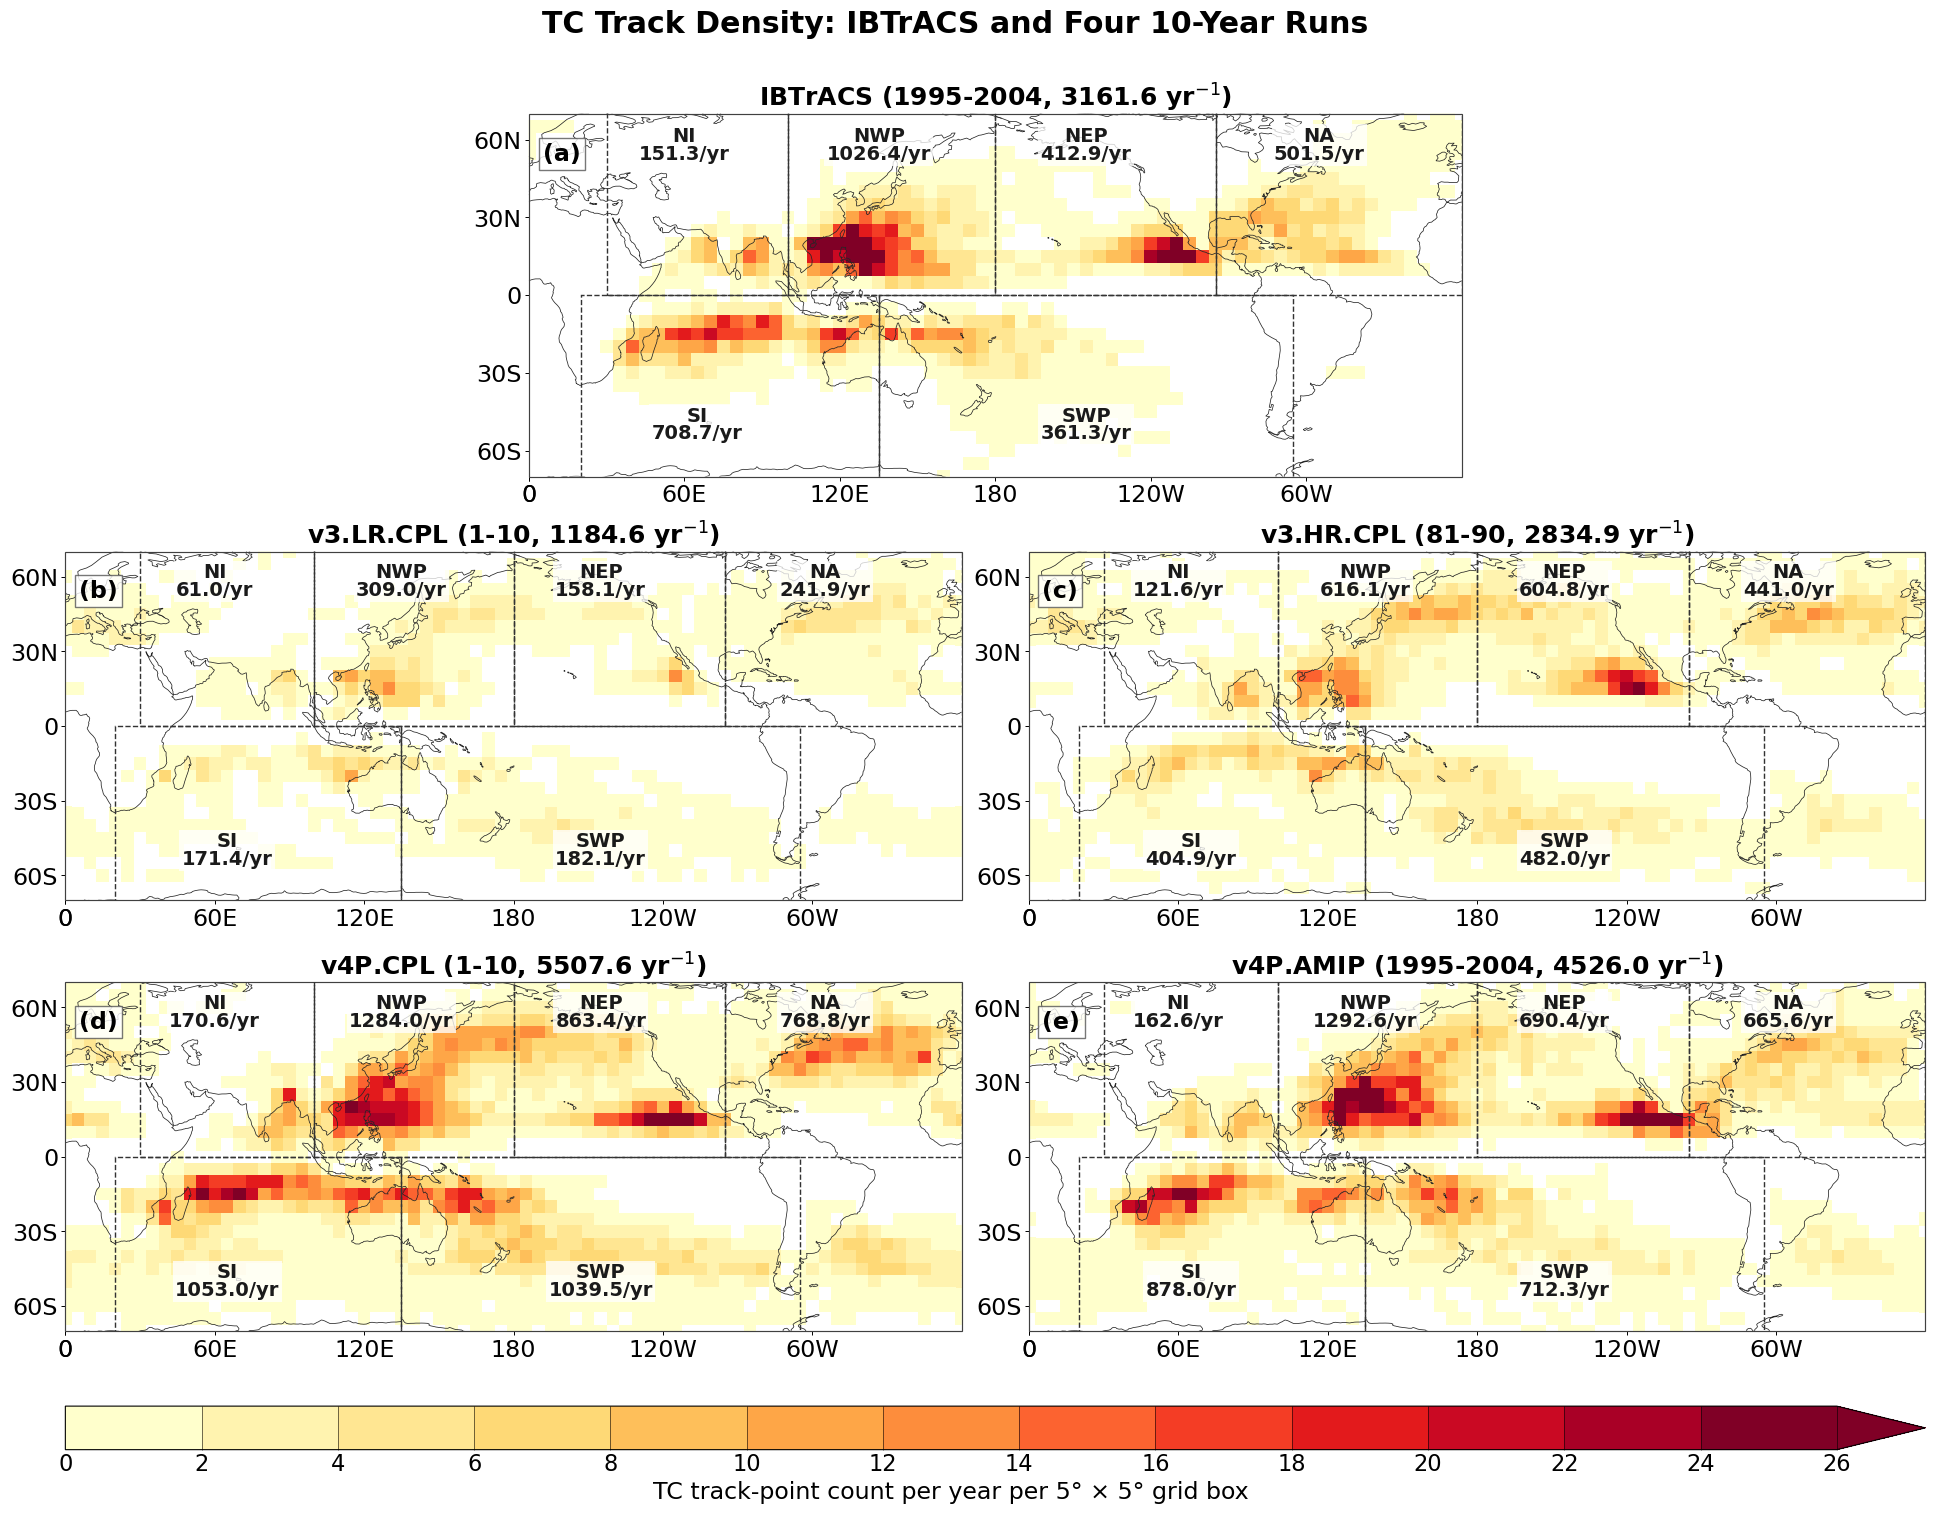

In [133]:
def coord_edges(coord: xr.DataArray) -> np.ndarray:
    values = np.asarray(coord.values, dtype=float)
    if values.size < 2:
        raise ValueError("Need at least two coordinate values to infer cell edges")
    mids = 0.5 * (values[:-1] + values[1:])
    first = values[0] - 0.5 * (values[1] - values[0])
    last = values[-1] + 0.5 * (values[-1] - values[-2])
    return np.concatenate([[first], mids, [last]])


def lon_label(x):
    x = int(x) % 360
    if x == 0:
        return "0"
    if x == 180:
        return "180"
    return f"{x}E" if x < 180 else f"{360 - x}W"


def lat_label(y):
    y = int(y)
    if y == 0:
        return "0"
    return f"{abs(y)}N" if y > 0 else f"{abs(y)}S"


def plot_density_panel(ax, field: xr.DataArray, title: str, levels: np.ndarray, cmap, panel_label: str | None = None):
    field = field.transpose("lat", "lon")
    data = field.where(field > 0)
    mesh = ax.pcolormesh(
        coord_edges(field["lon"]),
        coord_edges(field["lat"]),
        data.values,
        cmap=cmap,
        norm=mcolors.BoundaryNorm(levels, cmap.N),
        transform=ccrs.PlateCarree(),
        shading="flat",
    )
    ax.set_extent(PLOT_EXTENT, crs=ccrs.PlateCarree())
    ax.coastlines(linewidth=FIG_COASTLINE_LINEWIDTH, color="0.15")
    add_tc_basin_boxes(ax, field)
    ax.set_title(title, fontsize=FIG_PANEL_TITLE_SIZE, fontweight="bold", pad=FIG_TITLE_PAD)

    xticks = np.arange(0, 361, 60)
    yticks = [-60, -30, 0, 30, 60]
    ax.set_xticks(xticks, crs=ccrs.PlateCarree())
    ax.set_xticklabels([lon_label(x) for x in xticks], fontsize=FIG_TICK_SIZE)
    ax.set_yticks(yticks, crs=ccrs.PlateCarree())
    ax.set_yticklabels([lat_label(y) for y in yticks], fontsize=FIG_TICK_SIZE)
    ax.tick_params(axis="both", which="major", direction="out", length=FIG_TICK_LENGTH, width=FIG_TICK_WIDTH,
                   top=False, right=False, labeltop=False, labelright=False, pad=FIG_TICK_PAD)
    for spine in ax.spines.values():
        spine.set_linewidth(FIG_SPINE_LINEWIDTH)
        spine.set_color("0.25")
    if panel_label is not None:
        ax.text(
            FIG_PANEL_LABEL_XY[0], FIG_PANEL_LABEL_XY[1], panel_label, transform=ax.transAxes,
            ha="left", va="top", fontsize=FIG_PANEL_LABEL_SIZE, fontweight="bold",
            bbox={"facecolor": "white", "edgecolor": "0.35", "boxstyle": "square,pad=0.18", "alpha": FIG_LABEL_BOX_ALPHA},
        )
    return mesh


def basin_integrated_count(field: xr.DataArray, basin: dict) -> float:
    field = field.transpose("lat", "lon")
    lon = field["lon"] % 360.0
    lat = field["lat"]
    in_lon = (lon >= basin["lon1"]) & (lon < basin["lon2"])
    in_lat = (lat >= basin["lat1"]) & (lat <= basin["lat2"])
    return float(field.where(in_lon & in_lat).sum(skipna=True))


def format_basin_label(name: str, count: float) -> str:
    suffix = "/yr" if ANNUALIZE else ""
    return f"{name}\n{count:.{TC_BASIN_COUNT_DECIMALS}f}{suffix}"


def add_tc_basin_boxes(ax, field: xr.DataArray | None = None, show_counts: bool = True):
    if not SHOW_TC_BASINS:
        return
    import matplotlib.patches as mpatches

    for name, basin in TC_BASINS.items():
        rect = mpatches.Rectangle(
            (basin["lon1"], basin["lat1"]),
            basin["lon2"] - basin["lon1"],
            basin["lat2"] - basin["lat1"],
            fill=False,
            linewidth=TC_BASIN_LINEWIDTH,
            linestyle=TC_BASIN_LINESTYLE,
            edgecolor=TC_BASIN_EDGE_COLOR,
            transform=ccrs.PlateCarree(),
            zorder=6,
        )
        ax.add_patch(rect)
        if SHOW_TC_BASIN_LABELS:
            label_text = name
            if show_counts and field is not None:
                basin_count = basin_integrated_count(field, basin)
                label_text = format_basin_label(name, basin_count)
            ax.text(
                basin["text_xy"][0], basin["text_xy"][1], label_text,
                transform=ccrs.PlateCarree(),
                ha="center", va="center",
                fontsize=TC_BASIN_LABEL_SIZE,
                fontweight="bold",
                color=TC_BASIN_LABEL_COLOR,
                linespacing=0.92,
                bbox={
                    "facecolor": "white",
                    "edgecolor": "none",
                    "boxstyle": "square,pad=0.12",
                    "alpha": TC_BASIN_LABEL_ALPHA,
                },
                zorder=7,
            )


def build_density_figure_axes(fig, plot_runs):
    if INCLUDE_OBS_REFERENCE and plot_runs and plot_runs[0].get("source") == "obs" and len(plot_runs) == 5:
        grid = fig.add_gridspec(
            4, 2,
            height_ratios=[1.0, 1.0, 1.0, FIG_COLORBAR_HEIGHT_RATIO],
            left=FIG_GRID_LEFT, right=FIG_GRID_RIGHT, top=FIG_GRID_TOP_WITH_OBS, bottom=FIG_GRID_BOTTOM_WITH_OBS,
            hspace=FIG_PANEL_HSPACE, wspace=FIG_PANEL_WSPACE,
        )
        axes = [fig.add_subplot(grid[0, :], projection=ccrs.PlateCarree(central_longitude=180))]
        axes.extend([
            fig.add_subplot(grid[1, 0], projection=ccrs.PlateCarree(central_longitude=180)),
            fig.add_subplot(grid[1, 1], projection=ccrs.PlateCarree(central_longitude=180)),
            fig.add_subplot(grid[2, 0], projection=ccrs.PlateCarree(central_longitude=180)),
            fig.add_subplot(grid[2, 1], projection=ccrs.PlateCarree(central_longitude=180)),
        ])
        cax = fig.add_subplot(grid[3, :])
        return axes, cax

    n_panels = len(plot_runs)
    ncols = 2
    nrows = int(np.ceil(n_panels / ncols))
    grid = fig.add_gridspec(
        nrows + 1, ncols,
        height_ratios=[1.0] * nrows + [FIG_COLORBAR_HEIGHT_RATIO],
        left=FIG_GRID_LEFT, right=FIG_GRID_RIGHT, top=FIG_GRID_TOP_DEFAULT, bottom=FIG_GRID_BOTTOM_DEFAULT,
        hspace=FIG_PANEL_HSPACE, wspace=FIG_PANEL_WSPACE,
    )
    axes = [fig.add_subplot(grid[i // ncols, i % ncols], projection=ccrs.PlateCarree(central_longitude=180)) for i in range(n_panels)]
    cax = fig.add_subplot(grid[-1, :])
    return axes, cax


if RUN_PLOTS:
    finite_max = max(float(field.max(skipna=True)) for field in DENSITIES.values())
    if LEVEL_MODE == "fixed":
        levels = np.asarray(FIXED_LEVELS, dtype=float)
    else:
        upper = max(1.0, np.ceil(finite_max))
        step = max(1.0, np.ceil(upper / 12.0))
        levels = np.arange(0.0, upper + step, step)
        if len(levels) < 3:
            levels = np.array([0.0, 0.5, 1.0])

    cmap = plt.get_cmap(CMAP, len(levels) - 1).copy()
    cmap.set_bad((1, 1, 1, 0))

    fig = plt.figure(figsize=FIGSIZE)
    axes, cax = build_density_figure_axes(fig, PLOT_RUNS)
    panel_labels = [f"({chr(97 + i)})" for i in range(len(PLOT_RUNS))]

    im = None
    for ax, run, panel_label in zip(axes, PLOT_RUNS, panel_labels):
        label = run["label"]
        total = float(DENSITIES[label].sum(skipna=True))
        total_text = f"{total:.{TC_PANEL_TOTAL_DECIMALS}f} yr$^{{-1}}$" if ANNUALIZE else f"{total:.{TC_PANEL_TOTAL_DECIMALS}f}"
        title = f"{label} ({run['year_range']}, {total_text})"
        im = plot_density_panel(ax, DENSITIES[label], title, levels, cmap, panel_label=panel_label)

    units = "TC track points yr-1" if ANNUALIZE else "TC track points"
    if DENSITY_SOURCE == "histogram" and not INCLUDE_OBS_REFERENCE:
        units = "TC histogram count yr-1" if ANNUALIZE else "TC histogram count"
    cbar = fig.colorbar(
        im, cax=cax, orientation="horizontal",
        ticks=levels, extend="max", drawedges=True,
    )
    cbar.set_label(f"TC track-point count per year per {GRID_SIZE:g}° × {GRID_SIZE:g}° grid box", fontsize=FIG_COLORBAR_LABEL_SIZE, labelpad=FIG_COLORBAR_LABEL_PAD)
    cbar.ax.tick_params(labelsize=FIG_COLORBAR_TICK_SIZE, length=0, pad=FIG_TICK_PAD)

    fig.suptitle("TC Track Density: IBTrACS and Four 10-Year Runs", fontsize=FIG_SUPTITLE_SIZE, fontweight="bold", y=FIG_SUPTITLE_Y)
   #fig.text(
   #     FIG_FOOTNOTE_XY[0], FIG_FOOTNOTE_XY[1],
   #     f"IBTrACS filter: >= {OBS_WIND_MIN_MS:g} m/s, hours {OBS_SYNOPTIC_HOURS}; model tracks: max_topograph <= {MODEL_MAX_TOPOGRAPH_M:g} m",
   #     ha="right", va="bottom", fontsize=FIG_FOOTNOTE_SIZE, color="0.25",
   # )

    if SAVE_FIGURES:
        obs_tag = "with_ibtracs" if INCLUDE_OBS_REFERENCE else "models_only"
        out_file = OUTPUT_DIR / f"tc_track_density_4model_{obs_tag}_{DENSITY_SOURCE}_{GRID_SIZE:g}deg.png"
        fig.savefig(out_file, dpi=DPI, bbox_inches="tight")
        print(f"Saved {out_file}")
    plt.show()
else:
    print("Set RUN_PLOTS = True after checking the resolved inputs and density summaries above.")


## ENSO Regression Map

Regress annual TC track-point density against Niño-3.4. By default, this block generates one consistent Niño-3.4 NetCDF per panel from the run's 10-year `cmip_ts/monthly` TS files, mapping the generated annual index onto the TC track-file years. You can still override any panel with a precomputed index through `REG_NINO_FILE_BY_LABEL`.


IBTrACS: regression years 1995-2004 (10 years), Niño file=/global/cfs/cdirs/e3sm/www/zhan391/eamxx-pcmdi/analysis_output/tc_track_density/nino34_IBTrACS_1995-2004.nc
v3.LR.CPL: regression years 1-10 (10 years), Niño file=/global/cfs/cdirs/e3sm/www/zhan391/eamxx-pcmdi/analysis_output/tc_track_density/nino34_v3-LR-CPL_1-10.nc
v3.HR.CPL: regression years 81-90 (10 years), Niño file=/global/cfs/cdirs/e3sm/www/zhan391/eamxx-pcmdi/analysis_output/tc_track_density/nino34_v3-HR-CPL_81-90.nc
v4P.CPL: regression years 1-10 (10 years), Niño file=/global/cfs/cdirs/e3sm/www/zhan391/eamxx-pcmdi/analysis_output/tc_track_density/nino34_v4P-CPL_1-10.nc
v4P.AMIP: regression years 1995-2004 (10 years), Niño file=/global/cfs/cdirs/e3sm/www/zhan391/eamxx-pcmdi/analysis_output/tc_track_density/nino34_v4P-AMIP_1995-2004.nc


Saved /global/cfs/cdirs/e3sm/www/zhan391/eamxx-pcmdi/analysis_output/tc_track_density/tc_track_density_nino34_regression_5deg.png


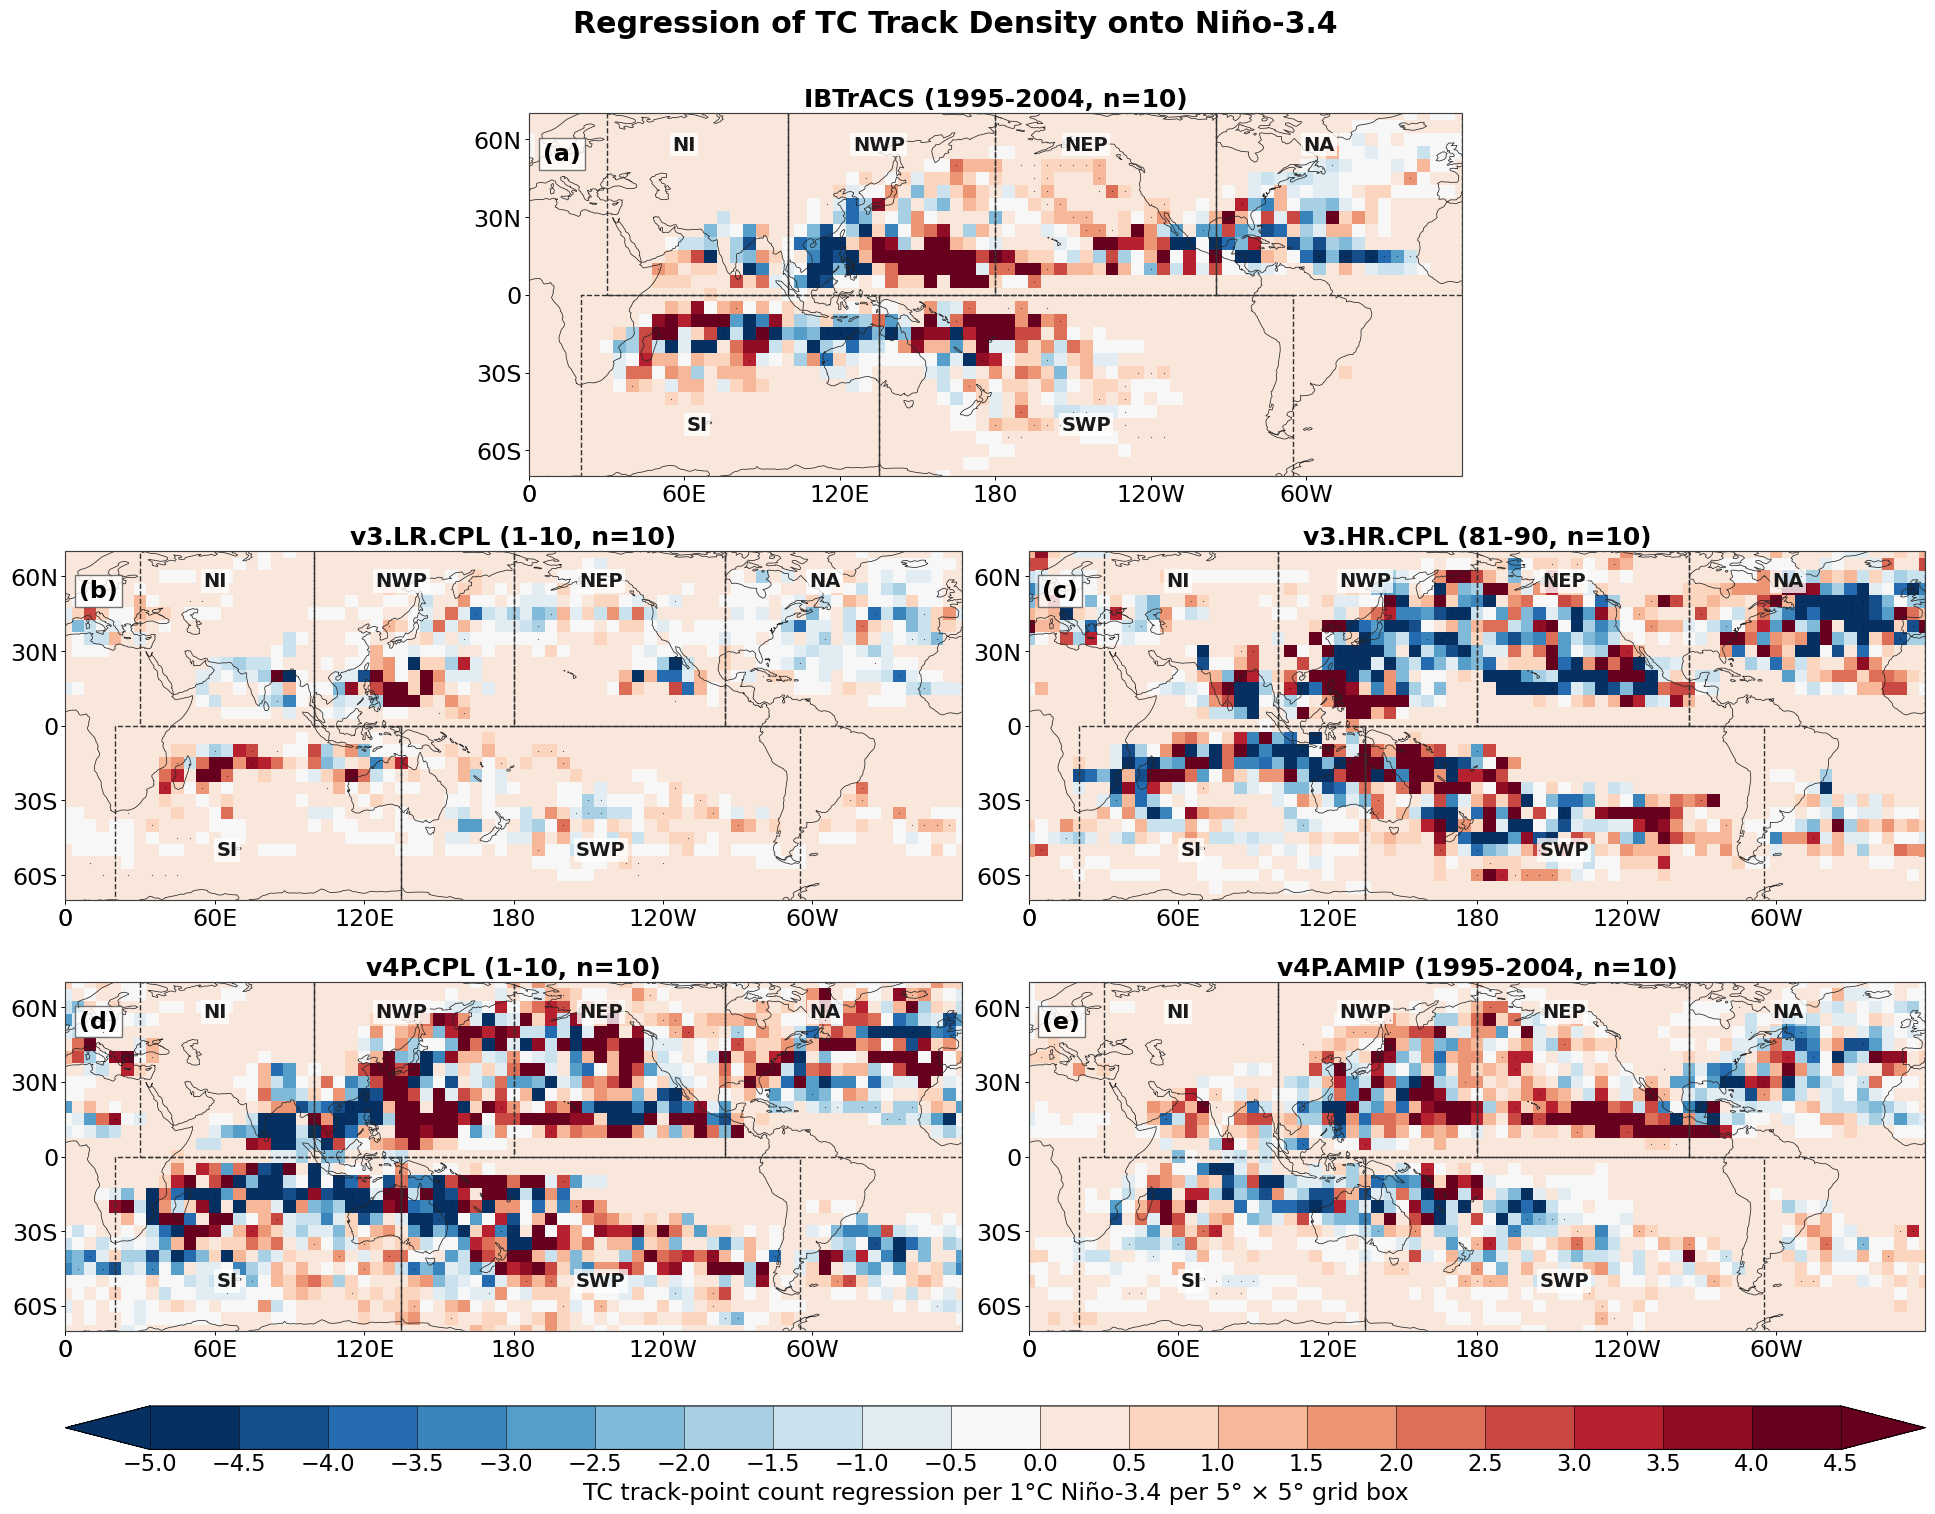

In [134]:
def parse_stitchnodes_track_points(path: Path) -> dict:
    """Return lat, lon, year, and storm ids from a TempestExtremes track file."""
    lat = []
    lon = []
    year = []
    storm_id = []
    current_storm = -1

    with open(path) as fh:
        for line in fh:
            text = line.strip()
            if not text or text.startswith("#"):
                continue
            if text.startswith("start"):
                current_storm += 1
                continue

            parts = text.split()
            if len(parts) >= 10 and abs(float(parts[3])) <= 90.0:
                lon_value = float(parts[2])
                lat_value = float(parts[3])
                year_value = int(float(parts[7])) if len(parts) >= 11 else int(float(parts[6]))
            elif len(parts) >= 10:
                lon_value = float(parts[1])
                lat_value = float(parts[2])
                year_value = int(float(parts[6]))
            else:
                continue

            lon.append(lon_value % 360.0)
            lat.append(lat_value)
            year.append(year_value)
            storm_id.append(current_storm)

    return {
        "lat": np.asarray(lat, dtype=float),
        "lon": np.asarray(lon, dtype=float),
        "year": np.asarray(year, dtype=int),
        "storm_id": np.asarray(storm_id, dtype=int),
    }


def track_density_by_year(lat, lon, years, year_values) -> xr.DataArray:
    fields = []
    config = TrackDensityConfig(method="box", box_grid_size=GRID_SIZE)
    for year_value in year_values:
        use = years == year_value
        if np.any(use):
            density = compute_track_density(lat[use], lon[use], config=config)
        else:
            density = compute_track_density([], [], config=config)
        fields.append(density)
    out = xr.concat(fields, dim=xr.DataArray(year_values, dims="year", name="year"))
    out.name = "annual_track_density"
    return out


def load_model_annual_density(run: dict) -> xr.DataArray:
    points = parse_stitchnodes_track_points(run["track_path"])
    start, end = run["year_range"].split("-")
    year_values = np.arange(int(start), int(end) + 1, dtype=int)
    density = track_density_by_year(points["lat"], points["lon"], points["year"], year_values)
    density.attrs.update(source=str(run["track_path"]), label=run["label"])
    return density


def load_ibtracs_annual_density(run: dict) -> xr.DataArray:
    ds = xr.open_dataset(run["path"], decode_times=True)
    lat_name, lon_name = _find_lat_lon_names(ds)
    lat = ds[lat_name]
    lon = ds[lon_name]
    time = _ibtracs_time_values(ds)

    if not np.issubdtype(time.dtype, np.datetime64):
        raise ValueError("IBTrACS time could not be decoded; cannot build annual regression samples.")

    mask = np.isfinite(lat) & np.isfinite(lon)
    mask = mask & (time.dt.year >= run["year_start"]) & (time.dt.year <= run["year_end"])
    if OBS_MATCH_MODEL_6HOURLY:
        mask = mask & time.dt.hour.isin(OBS_SYNOPTIC_HOURS)

    wind = _combined_ibtracs_wind(ds, OBS_WIND_VARIABLES)
    if wind is not None:
        mask = mask & np.isfinite(wind) & (wind >= OBS_WIND_MIN_KT)

    lat_values = lat.where(mask).values.ravel()
    lon_values = lon.where(mask).values.ravel()
    year_values_all = time.dt.year.where(mask).values.ravel()
    valid = np.isfinite(lat_values) & np.isfinite(lon_values) & np.isfinite(year_values_all)

    lat_values = lat_values[valid]
    lon_values = lon_values[valid]
    point_years = year_values_all[valid].astype(int)
    year_values = np.arange(run["year_start"], run["year_end"] + 1, dtype=int)
    density = track_density_by_year(lat_values, lon_values, point_years, year_values)
    density.attrs.update(source=str(run["path"]), label=run["label"])
    return density


def _guess_sst_var(ds: xr.Dataset, preferred: str | None = None) -> str:
    if preferred and preferred in ds.data_vars:
        return preferred
    for name in ["ts", "TS", "sst", "SST", "tos", "TREFHT"]:
        if name in ds.data_vars:
            return name
    candidates = [name for name, da in ds.data_vars.items() if {"time", "lat", "lon"}.issubset(set(da.dims))]
    if candidates:
        return candidates[0]
    raise ValueError("Could not infer SST/TS variable. Set REG_SST_VAR explicitly.")


def _time_year_month(time_coord) -> tuple[np.ndarray, np.ndarray]:
    dt = time_coord.dt
    return dt.year.values.astype(int), dt.month.values.astype(int)


def _open_sst_files(paths: list[Path] | tuple[Path, ...]) -> xr.Dataset:
    paths = [Path(path) for path in paths]
    if not paths:
        raise FileNotFoundError("No SST/TS files were provided")
    missing = [str(path) for path in paths if not path.exists()]
    if missing:
        raise FileNotFoundError("Missing SST/TS files:\n" + "\n".join(missing))
    datasets = [xr.open_dataset(path, decode_times=True) for path in paths]
    try:
        ds = xr.concat(datasets, dim="time", data_vars="minimal", coords="minimal", compat="override").sortby("time") if len(datasets) > 1 else datasets[0]
    except Exception:
        for dataset in datasets:
            dataset.close()
        raise
    return ds


def build_nino34_from_sst_files(
    paths: list[Path] | tuple[Path, ...],
    target_years: np.ndarray,
    out_file: Path | None = None,
    *,
    varname: str | None = None,
    label: str | None = None,
) -> xr.Dataset:
    ds = _open_sst_files(paths)
    varname = _guess_sst_var(ds, varname)
    sst = ds[varname].astype(float)
    lon_name = "lon" if "lon" in sst.coords else "longitude"
    lat_name = "lat" if "lat" in sst.coords else "latitude"
    lon = (sst[lon_name] % 360.0)
    lat = sst[lat_name]
    lon1, lon2 = REG_NINO_LON_BOUNDS
    lat1, lat2 = REG_NINO_LAT_BOUNDS
    sst = sst.assign_coords({lon_name: lon}).sortby(lon_name)
    box = sst.sel({lon_name: slice(lon1, lon2), lat_name: slice(lat1, lat2)})
    if box.sizes.get(lon_name, 0) == 0 or box.sizes.get(lat_name, 0) == 0:
        raise ValueError(f"Empty Niño-3.4 box for {label or varname}: lon={REG_NINO_LON_BOUNDS}, lat={REG_NINO_LAT_BOUNDS}")
    weights = np.cos(np.deg2rad(box[lat_name]))
    nino_monthly = box.weighted(weights).mean((lat_name, lon_name), skipna=True)
    monthly_clim = nino_monthly.groupby("time.month").mean("time", skipna=True)
    nino_anom = nino_monthly.groupby("time.month") - monthly_clim
    source_years, source_months = _time_year_month(nino_anom["time"])
    if REG_NINO_MONTHS is not None:
        keep = np.isin(source_months, REG_NINO_MONTHS)
        nino_anom = nino_anom.isel(time=keep)
        source_years = source_years[keep]
    nino_ann = nino_anom.assign_coords(source_year=("time", source_years)).groupby("source_year").mean("time", skipna=True)
    source_year_values = nino_ann["source_year"].values.astype(int)
    target_years = np.asarray(target_years, dtype=int)
    n = min(source_year_values.size, target_years.size)
    if n < REG_MIN_YEARS:
        raise ValueError(f"Need at least {REG_MIN_YEARS} Niño years for {label or varname}; found {n}")
    if source_year_values.size != target_years.size:
        print(f"[WARN] {label or varname}: SST years ({source_year_values.size}) and track years ({target_years.size}) differ; using first {n} years by order.")
    nino_ann = nino_ann.isel(source_year=slice(0, n)).rename({"source_year": "year"})
    nino_ann = nino_ann.assign_coords(year=target_years[:n], source_year=("year", source_year_values[:n]))
    out = xr.Dataset(
        {
            "nino34": nino_ann,
            "nino34_ann": nino_ann,
        }
    )
    out["nino34"].attrs.update(
        long_name="Niño-3.4 monthly-climatology SST anomaly, annual mean",
        units=sst.attrs.get("units", "K"),
    )
    out.attrs.update(
        label=label or "",
        source=";".join(str(Path(path)) for path in paths),
        source_variable=varname,
        source_years=f"{source_year_values[:n].min()}-{source_year_values[:n].max()}",
        regression_years=f"{target_years[:n].min()}-{target_years[:n].max()}",
        nino34_lon_bounds=str(REG_NINO_LON_BOUNDS),
        nino34_lat_bounds=str(REG_NINO_LAT_BOUNDS),
        note="year matches TC track years; source_year records the SST file calendar year",
    )
    if out_file is not None:
        out_file = Path(out_file)
        out_file.parent.mkdir(parents=True, exist_ok=True)
        out.to_netcdf(out_file)
    ds.close()
    return out


def ensure_regression_nino_file(run: dict, annual_density: xr.DataArray) -> Path | None:
    label = run["label"]
    nino_path = REG_NINO_FILE_BY_LABEL.get(label)
    if nino_path is not None and Path(nino_path).exists():
        return Path(nino_path)
    if not REG_GENERATE_NINO_FILES:
        return Path(nino_path) if nino_path is not None else None
    sst_files = REG_SST_FILE_BY_LABEL.get(label, [])
    if not sst_files:
        return Path(nino_path) if nino_path is not None else None
    if nino_path is None:
        nino_path = OUTPUT_DIR / f"nino34_{label.replace('.', '-').replace(' ', '_')}_{run['year_range']}.nc"
        REG_NINO_FILE_BY_LABEL[label] = nino_path
    build_nino34_from_sst_files(
        sst_files,
        annual_density.year.astype(int).values,
        Path(nino_path),
        varname=REG_SST_VAR,
        label=label,
    )
    print(f"Generated {nino_path}")
    return Path(nino_path)


def _guess_nino_var(ds: xr.Dataset, preferred: str | None = None) -> str:
    if preferred and preferred in ds.data_vars:
        return preferred
    for name in ["nino34", "nino34_ann", "nino", "nino34_index", "oni"]:
        if name in ds.data_vars:
            return name
    one_dim = [name for name, da in ds.data_vars.items() if da.ndim == 1]
    if len(one_dim) == 1:
        return one_dim[0]
    raise ValueError("Could not infer Niño variable. Set REG_NINO_VAR explicitly.")


def load_regression_nino(path: Path, year_values: np.ndarray, varname: str | None = None) -> xr.DataArray:
    ds = xr.open_dataset(path)
    varname = _guess_nino_var(ds, varname)
    da = ds[varname].astype(float)
    extra_dims = [dim for dim in da.dims if dim not in {"time", "year"}]
    if extra_dims:
        da = da.mean(extra_dims, skipna=True)

    if "time" in da.dims:
        time = pd.to_datetime(da["time"].values)
        months = time.month
        years = time.year
        if REG_NINO_MONTHS is not None:
            keep = np.isin(months, REG_NINO_MONTHS)
            da = da.isel(time=keep)
            years = years[keep]
        nino = da.assign_coords(year=("time", years)).groupby("year").mean("time", skipna=True)
    elif "year" in da.dims:
        nino = da
    else:
        dim = da.dims[0]
        coord = da[dim].values if dim in da.coords else np.arange(da.sizes[dim])
        nino = da.assign_coords(year=(dim, coord.astype(int))).swap_dims({dim: "year"}).drop_vars(dim, errors="ignore")

    nino = nino.sel(year=np.intersect1d(nino.year.astype(int).values, year_values)).sortby("year")
    nino.name = "nino34"
    nino.attrs.update(source_file=str(path), source_variable=varname)
    return nino


def regress_density_on_nino(density: xr.DataArray, nino: xr.DataArray) -> xr.Dataset:
    density, nino = xr.align(density, nino, join="inner")
    if density.sizes.get("year", 0) < REG_MIN_YEARS:
        raise ValueError(f"Need at least {REG_MIN_YEARS} overlapping years; found {density.sizes.get('year', 0)}")

    valid = np.isfinite(density) & np.isfinite(nino)
    n = valid.sum("year")
    x = nino.where(valid)
    y = density.where(valid)
    x_anom = x - x.mean("year", skipna=True)
    y_anom = y - y.mean("year", skipna=True)
    cov = (x_anom * y_anom).sum("year", skipna=True)
    var_x = (x_anom ** 2).sum("year", skipna=True)
    var_y = (y_anom ** 2).sum("year", skipna=True)
    slope = (cov / var_x).where(n >= REG_MIN_YEARS)
    corr = (cov / np.sqrt(var_x * var_y)).where(n >= REG_MIN_YEARS)
    tval = corr * np.sqrt((n - 2) / (1 - corr ** 2))
    tval = tval.where(n >= REG_MIN_YEARS)
    try:
        from scipy.stats import t as student_t
        tcrit = xr.apply_ufunc(
            lambda n_: student_t.ppf(1.0 - (1.0 - REG_CONFIDENCE) / 2.0, np.maximum(n_ - 2, 1)),
            n.astype(float), vectorize=True,
        ).where(n >= REG_MIN_YEARS)
        sig = np.abs(tval) >= tcrit
    except Exception as exc:
        print(f"[WARN] scipy t-test unavailable ({exc}); significance markers disabled for this regression.")
        tcrit = xr.full_like(slope, np.nan)
        sig = xr.full_like(slope, False, dtype=bool)
    return xr.Dataset({"slope": slope, "corr": corr, "tval": tval, "tcrit": tcrit, "sig": sig, "n": n})


def load_annual_density_for_run(run: dict) -> xr.DataArray:
    return load_ibtracs_annual_density(run) if run.get("source") == "obs" else load_model_annual_density(run)


def plot_regression_panel(ax, field, sig, title, levels, cmap, panel_label):
    field = field.transpose("lat", "lon")
    im = ax.pcolormesh(
        coord_edges(field["lon"]), coord_edges(field["lat"]), field.values,
        cmap=cmap,
        norm=mcolors.BoundaryNorm(levels, cmap.N),
        transform=ccrs.PlateCarree(), shading="flat",
    )
    if REG_SHOW_SIGNIFICANCE_MARKERS:
        sig = sig.transpose("lat", "lon")
        sig_values = sig.values.astype(bool)
        if REG_SIGNIFICANCE_MARKER_STRIDE > 1:
            keep = np.zeros_like(sig_values, dtype=bool)
            keep[::REG_SIGNIFICANCE_MARKER_STRIDE, ::REG_SIGNIFICANCE_MARKER_STRIDE] = True
            sig_values &= keep
        yy, xx = np.where(sig_values)
        if yy.size:
            ax.scatter(
                sig["lon"].values[xx], sig["lat"].values[yy],
                s=REG_SIGNIFICANCE_MARKER_SIZE, marker=".", color="black", alpha=0.65,
                linewidths=0, transform=ccrs.PlateCarree(), zorder=8,
            )
    ax.set_extent(PLOT_EXTENT, crs=ccrs.PlateCarree())
    ax.coastlines(linewidth=FIG_COASTLINE_LINEWIDTH, color="0.15")
    add_tc_basin_boxes(ax, show_counts=False)
    ax.set_title(title, fontsize=FIG_PANEL_TITLE_SIZE, fontweight="bold", pad=FIG_TITLE_PAD)
    xticks = np.arange(0, 361, 60)
    yticks = [-60, -30, 0, 30, 60]
    ax.set_xticks(xticks, crs=ccrs.PlateCarree())
    ax.set_xticklabels([lon_label(x) for x in xticks], fontsize=FIG_TICK_SIZE)
    ax.set_yticks(yticks, crs=ccrs.PlateCarree())
    ax.set_yticklabels([lat_label(y) for y in yticks], fontsize=FIG_TICK_SIZE)
    ax.tick_params(axis="both", which="major", direction="out", length=FIG_TICK_LENGTH, width=FIG_TICK_WIDTH,
                   top=False, right=False, labeltop=False, labelright=False, pad=FIG_TICK_PAD)
    for spine in ax.spines.values():
        spine.set_linewidth(FIG_SPINE_LINEWIDTH)
        spine.set_color("0.25")
    ax.text(
        FIG_PANEL_LABEL_XY[0], FIG_PANEL_LABEL_XY[1], panel_label, transform=ax.transAxes,
        ha="left", va="top", fontsize=FIG_PANEL_LABEL_SIZE, fontweight="bold",
        bbox={"facecolor": "white", "edgecolor": "0.35", "boxstyle": "square,pad=0.18", "alpha": FIG_LABEL_BOX_ALPHA},
    )
    return im


if RUN_ENSO_REGRESSION:
    REGRESSION_RESULTS = {}
    skipped_regression = []
    for run in PLOT_RUNS:
        label = run["label"]
        annual_density = load_annual_density_for_run(run)
        nino_path = ensure_regression_nino_file(run, annual_density)
        if nino_path is None or not Path(nino_path).exists():
            skipped_regression.append(f"{label}: missing Niño file {nino_path}")
            continue
        nino = load_regression_nino(Path(nino_path), annual_density.year.astype(int).values, REG_NINO_VAR)
        try:
            reg = regress_density_on_nino(annual_density, nino)
        except ValueError as exc:
            skipped_regression.append(f"{label}: {exc}")
            continue
        REGRESSION_RESULTS[label] = {"run": run, "density": annual_density, "nino": nino, "reg": reg}
        print(f"{label}: regression years {int(nino.year.min())}-{int(nino.year.max())} ({nino.sizes['year']} years), Niño file={nino_path}")

    if skipped_regression:
        print("Skipped regression panels:")
        for message in skipped_regression:
            print(f"  {message}")

    if not REGRESSION_RESULTS:
        print("No regression panels available. Set REG_NINO_FILE or REG_NINO_FILE_BY_LABEL to valid Niño-3.4 NetCDF files.")
    else:
        slope_fields = [item["reg"]["slope"] for item in REGRESSION_RESULTS.values()]
        if REG_LEVEL_MODE == "fixed":
            reg_levels = np.asarray(REG_FIXED_LEVELS, dtype=float)
        else:
            values = np.concatenate([
                np.ravel(np.asarray(field.values, dtype=float))
                for field in slope_fields if np.isfinite(field.values).any()
            ])
            values = np.abs(values[np.isfinite(values)])
            limit = REG_COLOR_LIMIT_MIN if values.size == 0 else max(REG_COLOR_LIMIT_MIN, float(np.nanpercentile(values, REG_COLOR_LIMIT_PERCENTILE)))
            limit = np.ceil(limit / 10.0) * 10.0
            reg_levels = np.linspace(-limit, limit, 17)

        reg_cmap = plt.get_cmap(REG_CMAP, len(reg_levels) - 1).copy()
        reg_cmap.set_bad((1, 1, 1, 0))
        fig = plt.figure(figsize=REG_FIGSIZE)
        reg_runs = [item["run"] for item in REGRESSION_RESULTS.values()]
        axes, cax = build_density_figure_axes(fig, reg_runs)
        panel_labels = [f"({chr(97 + i)})" for i in range(len(reg_runs))]

        im = None
        for ax, (label, item), panel_label in zip(axes, REGRESSION_RESULTS.items(), panel_labels):
            reg = item["reg"]
            years = item["nino"].year.astype(int).values
            title = f"{label} ({years.min()}-{years.max()}, n={years.size})"
            im = plot_regression_panel(ax, reg["slope"], reg["sig"], title, reg_levels, reg_cmap, panel_label)

        cbar = fig.colorbar(im, cax=cax, orientation="horizontal", ticks=reg_levels, extend="both", drawedges=True)
        cbar.set_label(
            f"TC track-point count regression per 1°C Niño-3.4 per {GRID_SIZE:g}° × {GRID_SIZE:g}° grid box",
            fontsize=FIG_COLORBAR_LABEL_SIZE,
            labelpad=FIG_COLORBAR_LABEL_PAD,
        )
        cbar.ax.tick_params(labelsize=FIG_COLORBAR_TICK_SIZE, length=0, pad=FIG_TICK_PAD)
        fig.suptitle("Regression of TC Track Density onto Niño-3.4", fontsize=FIG_SUPTITLE_SIZE, fontweight="bold", y=FIG_SUPTITLE_Y)
        if SAVE_FIGURES:
            out_file = OUTPUT_DIR / f"tc_track_density_nino34_regression_{GRID_SIZE:g}deg.png"
            fig.savefig(out_file, dpi=DPI, bbox_inches="tight")
            print(f"Saved {out_file}")
        plt.show()
else:
    print("Set RUN_ENSO_REGRESSION = True to build Niño-3.4 regression maps.")


## Track-File Count Summary

In [135]:
summary_rows = []
if INCLUDE_OBS_REFERENCE:
    obs_density = DENSITIES[OBS_RUN["label"]]
    obs_total = float(obs_density.sum(skipna=True))
    summary_rows.append(
        {
            "label": OBS_RUN["label"],
            "year_range": OBS_RUN["year_range"],
            "nyears": OBS_RUN["nyears"],
            "storms": np.nan,
            "storms_per_year": np.nan,
            "track_points": obs_total * OBS_RUN["nyears"] if ANNUALIZE else obs_total,
            "track_points_per_year": obs_total if ANNUALIZE else obs_total / OBS_RUN["nyears"],
            "filter": (
                f">= {OBS_WIND_MIN_MS:g} m/s ({OBS_WIND_MIN_KT:.1f} kt); "
                f"hours {OBS_SYNOPTIC_HOURS}; "
                + (f"topo <= {OBS_MAX_TOPOGRAPH_M:g} m" if OBS_TOPOGRAPHY_PATH is not None else "topo not applied")
            ),
        }
    )

for run in TC_RUNS:
    lat, lon, storm_id = parse_stitchnodes_track(run["track_path"])
    unique_storms = np.unique(storm_id[storm_id >= 0])
    summary_rows.append(
        {
            "label": run["label"],
            "year_range": run["year_range"],
            "nyears": run["nyears"],
            "storms": len(unique_storms),
            "storms_per_year": len(unique_storms) / run["nyears"],
            "track_points": len(lat),
            "track_points_per_year": len(lat) / run["nyears"],
            "filter": f"TempestExtremes TC track; minWind={MODEL_MIN_WIND_MS:g} m/s; max_topograph={MODEL_MAX_TOPOGRAPH_M:g} m; 6-hourly",
        }
    )

try:
    import pandas as pd
    summary_df = pd.DataFrame(summary_rows)
    if "display" in globals():
        display(summary_df)
    else:
        print(summary_df.to_string(index=False))
except ImportError:
    for row in summary_rows:
        print(row)


    label year_range  nyears  storms  storms_per_year  track_points  track_points_per_year                                                                 filter
  IBTrACS  1995-2004      10     NaN              NaN  31616.000977            3161.600098             >= 8 m/s (15.6 kt); hours [0, 6, 12, 18]; topo not applied
v3.LR.CPL       1-10      10   660.0             66.0  11846.000000            1184.600000 TempestExtremes TC track; minWind=8 m/s; max_topograph=150 m; 6-hourly
v3.HR.CPL      81-90      10  1371.0            137.1  28349.000000            2834.900000 TempestExtremes TC track; minWind=8 m/s; max_topograph=150 m; 6-hourly
  v4P.CPL       1-10      10  2398.0            239.8  55076.000000            5507.600000 TempestExtremes TC track; minWind=8 m/s; max_topograph=150 m; 6-hourly
 v4P.AMIP  1995-2004      10  1754.0            175.4  45260.000000            4526.000000 TempestExtremes TC track; minWind=8 m/s; max_topograph=150 m; 6-hourly
